In [ ]:
!pip install kaggle

In [ ]:
import numpy as np
import pandas as pd
import io
import os
from glob import glob

In [ ]:
image_list = glob(os.path.join('/content/HAM10000_images_part_1/','*.jpg'))
image_list = image_list + glob(os.path.join('/content/HAM10000_images_part_2/','*.jpg'))
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in image_list}

In [ ]:
imageid_path_dict

{'ISIC_0024414': '/content/HAM10000_images_part_1/ISIC_0024414.jpg',
 'ISIC_0025384': '/content/HAM10000_images_part_1/ISIC_0025384.jpg',
 'ISIC_0024720': '/content/HAM10000_images_part_1/ISIC_0024720.jpg',
 'ISIC_0025810': '/content/HAM10000_images_part_1/ISIC_0025810.jpg',
 'ISIC_0025216': '/content/HAM10000_images_part_1/ISIC_0025216.jpg',
 'ISIC_0025162': '/content/HAM10000_images_part_1/ISIC_0025162.jpg',
 'ISIC_0028181': '/content/HAM10000_images_part_1/ISIC_0028181.jpg',
 'ISIC_0028293': '/content/HAM10000_images_part_1/ISIC_0028293.jpg',
 'ISIC_0028392': '/content/HAM10000_images_part_1/ISIC_0028392.jpg',
 'ISIC_0025941': '/content/HAM10000_images_part_1/ISIC_0025941.jpg',
 'ISIC_0027907': '/content/HAM10000_images_part_1/ISIC_0027907.jpg',
 'ISIC_0028333': '/content/HAM10000_images_part_1/ISIC_0028333.jpg',
 'ISIC_0026791': '/content/HAM10000_images_part_1/ISIC_0026791.jpg',
 'ISIC_0026291': '/content/HAM10000_images_part_1/ISIC_0026291.jpg',
 'ISIC_0025177': '/content/HAM1000

In [ ]:
print(pd.__version__)
#!pip install pandas==1.3.5


2.2.3


In [ ]:
data = pd.read_csv('/content/HAM10000_metadata.csv')
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
data.describe(exclude=[np.number])

,lesion_id,image_id,dx,dx_type,sex,localization
count,10015,10015,10015,10015,10015,10015
unique,7470,10015,7,4,3,15
top,HAM_0000835,ISIC_0032258,nv,histo,male,back
freq,6,1,6705,5340,5406,2192


In [ ]:
data.isna().any()

,0
lesion_id,False
image_id,False
dx,False
dx_type,False
age,True
sex,False
localization,False


In [ ]:
data.isna().any().sum()

np.int64(1)

In [ ]:
data['age'].fillna(value=int(data['age'].mean()), inplace=True)
data['age'] = data['age'].astype('int32')

/tmp/ipykernel_3875/3297284176.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(value=int(data['age'].mean()), inplace=True)


In [ ]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi (nv)',
    'mel': 'Melanoma (mel)',
    'bkl': 'Benign keratosis-like lesions (bkl)',
    'bcc': 'Basal cell carcinoma (bcc)',
    'akiec': 'Actinic keratoses (akiec)',
    'vasc': 'Vascular lesions (vasc)',
    'df': 'Dermatofibroma (df)'
}

data['cell_type'] = data['dx'].map(lesion_type_dict.get)
data['path'] = data['image_id'].map(imageid_path_dict.get)

data.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75,male,ear,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_2/ISIC_0031633.jpg


In [ ]:
# 4. 이미지 시각화 하기.

from PIL import Image
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data['image_pixel'] = data['path'].map(lambda x: np.asarray(Image.open(x).resize((28,28))))
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path,image_pixel
0,HAM_0000118,ISIC_0027419,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0027419.jpg,"[[[192, 153, 193], [195, 155, 192], [197, 154,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0025030.jpg,"[[[27, 16, 32], [69, 49, 76], [122, 93, 126], ..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0026769.jpg,"[[[192, 138, 153], [200, 144, 162], [202, 142,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80,male,scalp,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_1/ISIC_0025661.jpg,"[[[40, 21, 31], [95, 61, 73], [143, 102, 118],..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75,male,ear,Benign keratosis-like lesions (bkl),/content/HAM10000_images_part_2/ISIC_0031633.jpg,"[[[159, 114, 140], [194, 144, 173], [215, 162,..."


In [ ]:
sample_data = data.groupby('dx').apply(lambda df: df.iloc[0:2, [9, 7]])
sample_data

/tmp/ipykernel_3875/367743807.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_data = data.groupby('dx').apply(lambda df: df.iloc[0:2, [9, 7]])


image_pixel  \
dx                                                              
akiec 9687  [[[30, 14, 19], [37, 21, 28], [94, 69, 73], [1...   
      9688  [[[38, 22, 22], [87, 67, 66], [135, 112, 110],...   
bcc   2462  [[[16, 11, 12], [58, 46, 48], [177, 153, 149],...   
      2463  [[[197, 177, 198], [202, 188, 205], [207, 194,...   
bkl   0     [[[192, 153, 193], [195, 155, 192], [197, 154,...   
      1     [[[27, 16, 32], [69, 49, 76], [122, 93, 126], ...   
df    1095  [[[173, 132, 123], [195, 151, 144], [204, 162,...   
      1096  [[[220, 172, 180], [229, 180, 179], [240, 192,...   
mel   1211  [[[151, 126, 129], [161, 132, 138], [168, 140,...   
      1212  [[[201, 172, 187], [201, 173, 188], [203, 178,...   
nv    64    [[[163, 135, 159], [167, 140, 167], [170, 144,...   
      1210  [[[229, 145, 164], [229, 138, 162], [226, 133,...   
vasc  2320  [[[218, 189, 211], [221, 192, 214], [223, 190,...   
      2321  [[[162, 132, 132], [173, 142, 147], [180, 150,...   

                                      cell_type  
dx                                               
akiec 9687            Actinic keratoses (akiec)  
      9688            Actinic keratoses (akiec)  
bcc   2462           Basal cell carcinoma (bcc)  
      2463           Basal cell carcinoma (bcc)  
bkl   0     Benign keratosis-like lesions (bkl)  
      1     Benign keratosis-like lesions (bkl)  
df    1095                  Dermatofibroma (df)  
      1096                  Dermatofibroma (df)  
mel   1211                       Melanoma (mel)  
      1212                       Melanoma (mel)  
nv    64                  Melanocytic nevi (nv)  
      1210                Melanocytic nevi (nv)  
vasc  2320              Vascular lesions (vasc)  
      2321              Vascular lesions (vasc)

/tmp/ipykernel_3875/1567913604.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.imshow(np.squeeze(sample_data['image_pixel'][i]))
/tmp/ipykernel_3875/1567913604.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.title(sample_data['cell_type'][i])


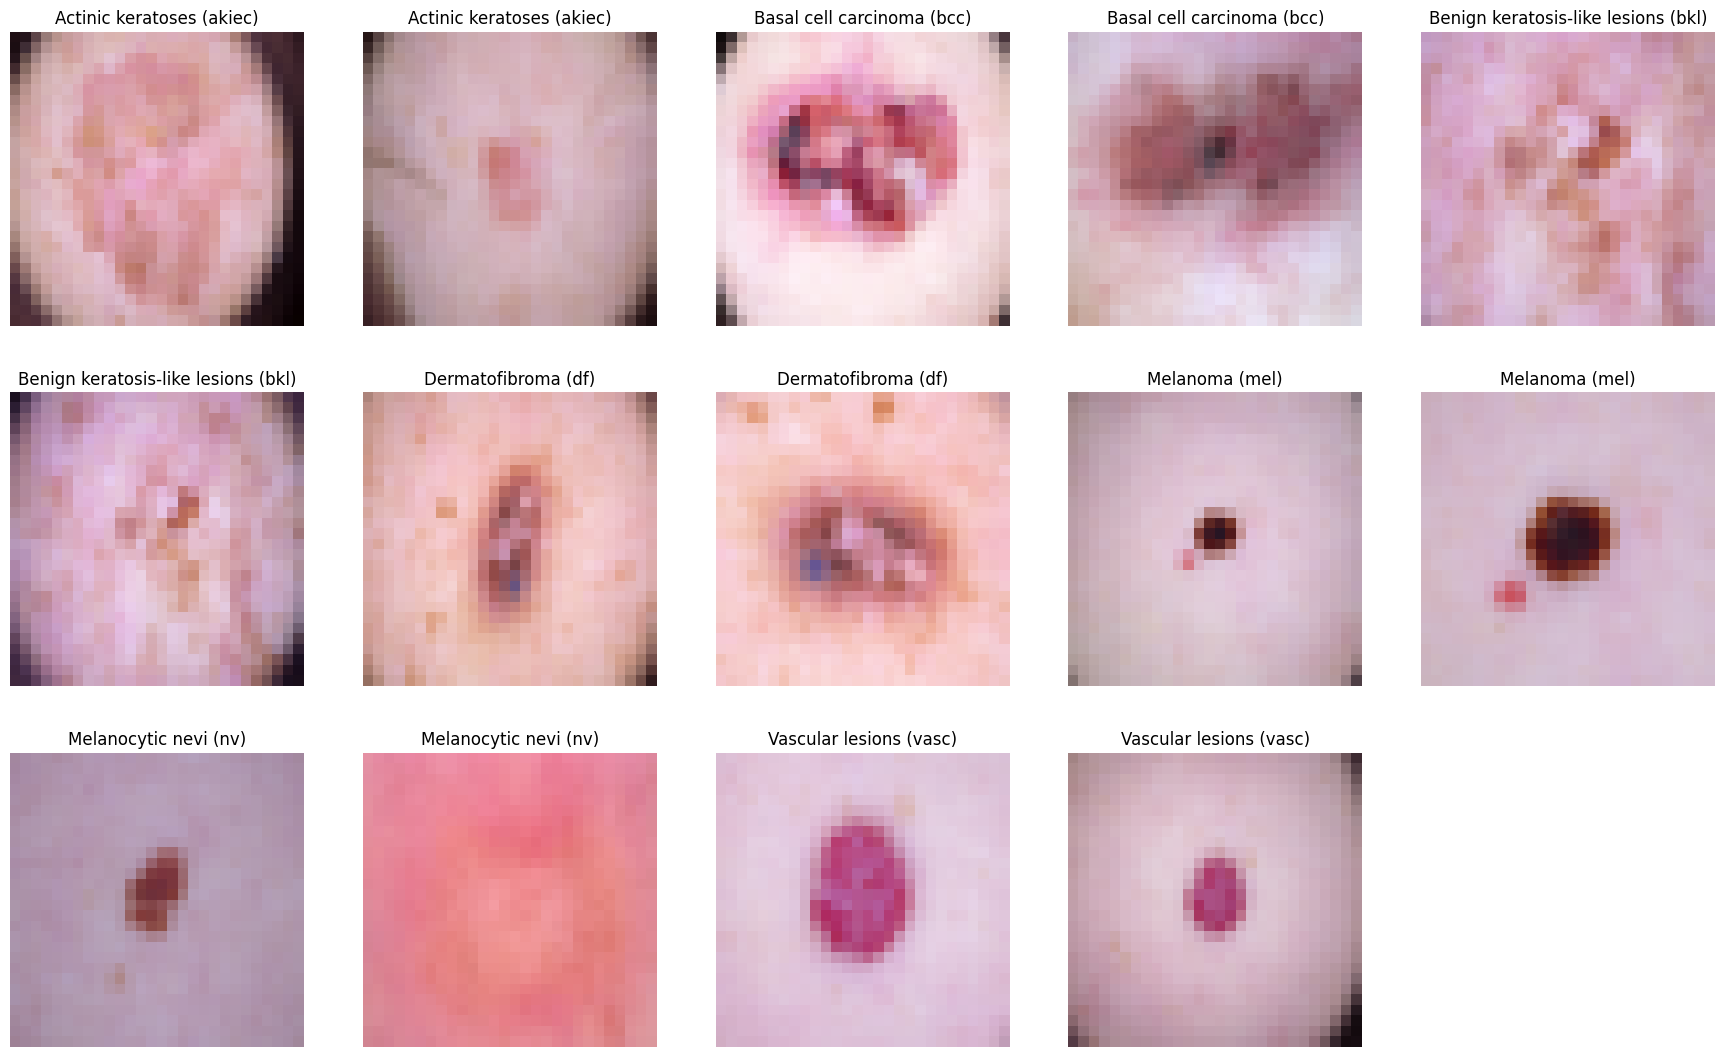

In [ ]:
plt.figure(figsize=(22, 32))
for i in range(14):
    plt.subplot(7, 5, i + 1)
    plt.imshow(np.squeeze(sample_data['image_pixel'][i]))
    plt.title(sample_data['cell_type'][i])
    plt.axis("off")
plt.show();

In [ ]:


label_mapping = {
    0: 'nv',
    1: 'mel',
    2: 'bkl',
    3: 'bcc',
    4: 'akiec',
    5: 'vasc',
    6: 'df'
}
reverse_label_mapping = dict((value, key) for key, value in label_mapping.items())
reverse_label_mapping
#{'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}


{'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6}

label
0    6705
1    1113
2    1099
3     514
4     327
5     142
6     115
Name: index, dtype: int64


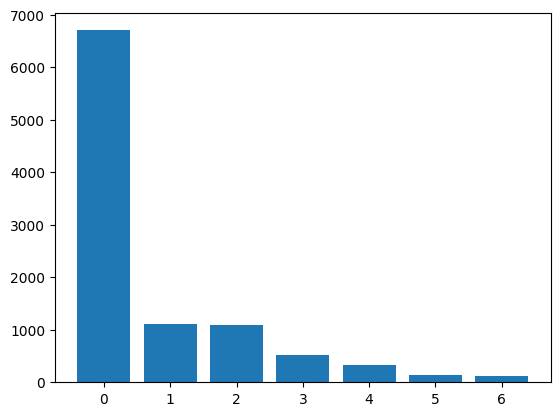

In [ ]:
data['label'] = data['dx'].map(reverse_label_mapping.get)

data = data.sort_values('label')
data = data.reset_index()

plt.bar([0,1,2,3,4,5,6], data.groupby('label')['index'].count())
print(data.groupby('label')['index'].count())

In [ ]:
print(pd.__version__)

2.2.3


In [ ]:
counter = 0
frames = [data]
for i in [4, 4, 11, 17, 45, 52]:
    counter += 1
    index = data[data['label'] == counter].index.values
    df_index = data.iloc[int(min(index)):int(max(index)+1)]

    # append 대신 pd.concat을 사용합니다.
    df_index = pd.concat([df_index] * (i + 1), ignore_index=True)
    frames.append(df_index)

final_data = pd.concat(frames, ignore_index=True)

print(data.shape)
print(final_data.shape)

(10015, 12)
(45756, 12)


label
0    6705
1    6678
2    6594
3    6682
4    6213
5    6674
6    6210
Name: index, dtype: int64
(45756, 28, 28, 3)
(45756, 1)


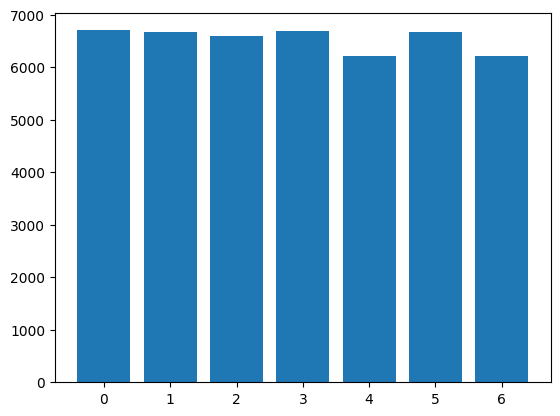

In [ ]:
plt.bar([0,1,2,3,4,5,6], final_data.groupby('label')['index'].count())
print(final_data.groupby('label')['index'].count())

X_aug = final_data['image_pixel'].to_numpy()
X_aug = np.stack(X_aug, axis=0)
Y_aug = np.array(final_data.iloc[:, -1:])
print(X_aug.shape)
print(Y_aug.shape)

In [ ]:

#CNN 이미지 학습

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold

In [ ]:
# 훈련된 데이터와 테스트 데이터 분할
tf.random.set_seed(3)
X_train, X_test, Y_train, Y_test = train_test_split(X_aug, Y_aug, test_size=0.2, random_state=3)

train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 10,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  horizontal_flip = True,
                                  vertical_flip = True,
                                  fill_mode = 'nearest')
train_datagen.fit(X_train)

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen.fit(X_test)

In [ ]:
def create_model():
    model = Sequential()
    model.add(Conv2D(16, kernel_size = (3,3), input_shape = (28, 28, 3), activation = 'relu', padding = 'same'))
    model.add(MaxPool2D(pool_size = (2,2)))

    model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu', padding = 'same'))
    model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))

    model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu', padding = 'same'))
    model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))

    model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu', padding = 'same'))
    model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))

    model.add(Flatten())
    model.add(Dense(64, activation = 'relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(7, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)

    model.compile(loss = 'sparse_categorical_crossentropy',
                 optimizer = optimizer,
                  metrics = ['accuracy'])
    print(model.summary())
    return model;

In [ ]:
def train_model(model, X_train, Y_train, EPOCHS):
    early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='auto')

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='auto')

    history = model.fit(X_train, Y_train, validation_split=0.2, batch_size = 64, epochs = EPOCHS,
                        callbacks = [reduce_lr, early_stop])
    return history

In [ ]:
def plot_model_training_curve(history):
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Model Accuracy', 'Model Loss'])
    fig.add_trace(
        go.Scatter(
            y=history.history['accuracy'], name='train_acc'), row=1, col=1)
    fig.add_trace(
        go.Scatter(
            y=history.history['val_accuracy'], name='val_acc'), row=1, col=1)
    fig.add_trace(
        go.Scatter(
            y=history.history['loss'], name='train_loss'), row=1, col=2)
    fig.add_trace(
        go.Scatter(
            y=history.history['val_loss'], name='val_loss'), row=1, col=2)
    fig.show()

In [ ]:
num_folds = 5
acc_per_fold=[]
loss_per_fold=[]
kfold = StratifiedKFold(n_splits=num_folds, shuffle=True)
fold_no=1
epochs = 50
model=create_model()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,583 (517.90 KB)

 Trainable params: 132,583 (517.90 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# 이제 kfold,split()에 훈련 데이터로 교차 검증하면서 학습하고 결과 정보를  출력 및 시각화.
for train,test in kfold.split(X_train, Y_train):
  print('------------------------------------------------------------------------')
  print(f'Training for fold {fold_no} ...')
  history = train_model(model, X_train[train], Y_train[train],EPOCHS=epochs)
  plot_model_training_curve(history)

  scores = model.evaluate(X_train[test], Y_train[test], verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])
  model_file='skin_caner_5folds_'+str(fold_no)+'.h5'
  model.save(model_file)

  fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.4752 - loss: 1.7307 - val_accuracy: 0.5366 - val_loss: 1.1506 - learning_rate: 0.0010
Epoch 2/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.6596 - loss: 0.8962 - val_accuracy: 0.7084 - val_loss: 0.7837 - learning_rate: 0.0010
Epoch 3/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.7582 - loss: 0.6447 - val_accuracy: 0.7722 - val_loss: 0.6083 - learning_rate: 0.0010
Epoch 4/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8213 - loss: 0.4838 - val_accuracy: 0.8139 - val_loss: 0.5101 - learning_rate: 0.0010
Epoch 5/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8627 - loss: 0.3779 - val_accuracy: 0.8439 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 6/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8885 - loss: 0.3082 - val_accuracy: 0.8774 - val_loss: 0.3376 - l

Score for fold 1: loss of 0.12205570936203003; compile_metrics of 97.04958200454712%
------------------------------------------------------------------------
Training for fold 2 ...
Epoch 1/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 33s 91ms/step - accuracy: 0.9921 - loss: 0.0344 - val_accuracy: 0.9749 - val_loss: 0.1075 - learning_rate: 1.0000e-07
Epoch 2/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - accuracy: 0.9925 - loss: 0.0336 - val_accuracy: 0.9752 - val_loss: 0.1053 - learning_rate: 1.0000e-07
Epoch 3/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.9926 - loss: 0.0331 - val_accuracy: 0.9758 - val_loss: 0.1037 - learning_rate: 1.0000e-07
Epoch 4/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9928 - loss: 0.0327 - val_accuracy: 0.9759 - val_loss: 0.1023 - learning_rate: 1.0000e-07
Epoch 5/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.9928 - loss: 0.0323 - val_accuracy: 0.9763 - val_loss: 0.1011 - learning_rate: 1.0000e-07
Epoch 6/50
367/367 ━━━━━━━━━

Score for fold 2: loss of 0.02609502337872982; compile_metrics of 99.53558444976807%
------------------------------------------------------------------------
Training for fold 3 ...
Epoch 1/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.9942 - loss: 0.0278 - val_accuracy: 0.9790 - val_loss: 0.0893 - learning_rate: 1.0000e-07
Epoch 2/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 44s 86ms/step - accuracy: 0.9942 - loss: 0.0277 - val_accuracy: 0.9790 - val_loss: 0.0893 - learning_rate: 1.0000e-07
Epoch 3/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - accuracy: 0.9942 - loss: 0.0277 - val_accuracy: 0.9790 - val_loss: 0.0892 - learning_rate: 1.0000e-07
Epoch 4/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - accuracy: 0.9942 - loss: 0.0276 - val_accuracy: 0.9790 - val_loss: 0.0891 - learning_rate: 1.0000e-07
Epoch 5/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.9943 - loss: 0.0276 - val_accuracy: 0.9790 - val_loss: 0.0890 - learning_rate: 1.0000e-07
Epoch 6/50
367/367 ━━━━━━━━━

Score for fold 3: loss of 0.024295566603541374; compile_metrics of 99.54923987388611%
------------------------------------------------------------------------
Training for fold 4 ...
Epoch 1/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.9943 - loss: 0.0255 - val_accuracy: 0.9804 - val_loss: 0.0912 - learning_rate: 1.0000e-07
Epoch 2/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 43s 83ms/step - accuracy: 0.9943 - loss: 0.0254 - val_accuracy: 0.9804 - val_loss: 0.0911 - learning_rate: 1.0000e-07
Epoch 3/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9943 - loss: 0.0254 - val_accuracy: 0.9804 - val_loss: 0.0911 - learning_rate: 1.0000e-07
Epoch 4/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9943 - loss: 0.0254 - val_accuracy: 0.9804 - val_loss: 0.0910 - learning_rate: 1.0000e-07
Epoch 5/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.9943 - loss: 0.0253 - val_accuracy: 0.9805 - val_loss: 0.0910 - learning_rate: 1.0000e-07
Epoch 6/50
367/367 ━━━━━━━━

Score for fold 4: loss of 0.019919171929359436; compile_metrics of 99.49460625648499%
------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.9947 - loss: 0.0236 - val_accuracy: 0.9783 - val_loss: 0.0875 - learning_rate: 1.0000e-07
Epoch 2/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.9947 - loss: 0.0235 - val_accuracy: 0.9783 - val_loss: 0.0875 - learning_rate: 1.0000e-07
Epoch 3/50
367/367 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9947 - loss: 0.0235 - val_accuracy: 0.9783 - val_loss: 0.0875 - learning_rate: 1.0000e-07
Epoch 4/50
366/367 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9950 - loss: 0.0239
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-08.
367/367 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.9947 - loss: 0.0235 - val_accuracy: 0.9785 - val_loss: 0.0874 - learning_rate: 1.0000e-07
Epoch 5/50
367/367 ━━━━━━━━━━━━━━

Score for fold 5: loss of 0.020971596240997314; compile_metrics of 99.67213273048401%


In [ ]:
print('------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
  print('------------------------------------------------------------------------')
  print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print('------------------------------------------------------------------------')

------------------------------------------------------------------------
Score per fold
------------------------------------------------------------------------
> Fold 1 - Loss: 0.12205570936203003 - Accuracy: 97.04958200454712%
------------------------------------------------------------------------
> Fold 2 - Loss: 0.02609502337872982 - Accuracy: 99.53558444976807%
------------------------------------------------------------------------
> Fold 3 - Loss: 0.024295566603541374 - Accuracy: 99.54923987388611%
------------------------------------------------------------------------
> Fold 4 - Loss: 0.019919171929359436 - Accuracy: 99.49460625648499%
------------------------------------------------------------------------
> Fold 5 - Loss: 0.020971596240997314 - Accuracy: 99.67213273048401%
------------------------------------------------------------------------
Average scores for all folds:
> Accuracy: 99.06022906303406 (+- 1.0070655941951747)
> Loss: 0.04266741350293159
-------------------

In [ ]:
model_acc = model.evaluate(X_test, Y_test, verbose=0)[1]
print("Test Accuracy: {:.3f}%".format(model_acc * 100))

y_true = np.array(Y_test)
y_pred = model.predict(X_test)
y_pred = np.array(list(map(lambda x: np.argmax(x), y_pred)))
clr = classification_report(y_true, y_pred, target_names=label_mapping.values())
print(clr)

Test Accuracy: 97.837%
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

          nv       0.98      0.88      0.93      1373
         mel       0.94      0.99      0.96      1334
         bkl       0.95      0.99      0.97      1324
         bcc       0.99      1.00      0.99      1352
       akiec       1.00      1.00      1.00      1232
        vasc       1.00      1.00      1.00      1299
          df       1.00      1.00      1.00      1238

    accuracy                           0.98      9152
   macro avg       0.98      0.98      0.98      9152
weighted avg       0.98      0.98      0.98      9152



In [ ]:
sample_data = X_test[:15]
prediction = model.predict(sample_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


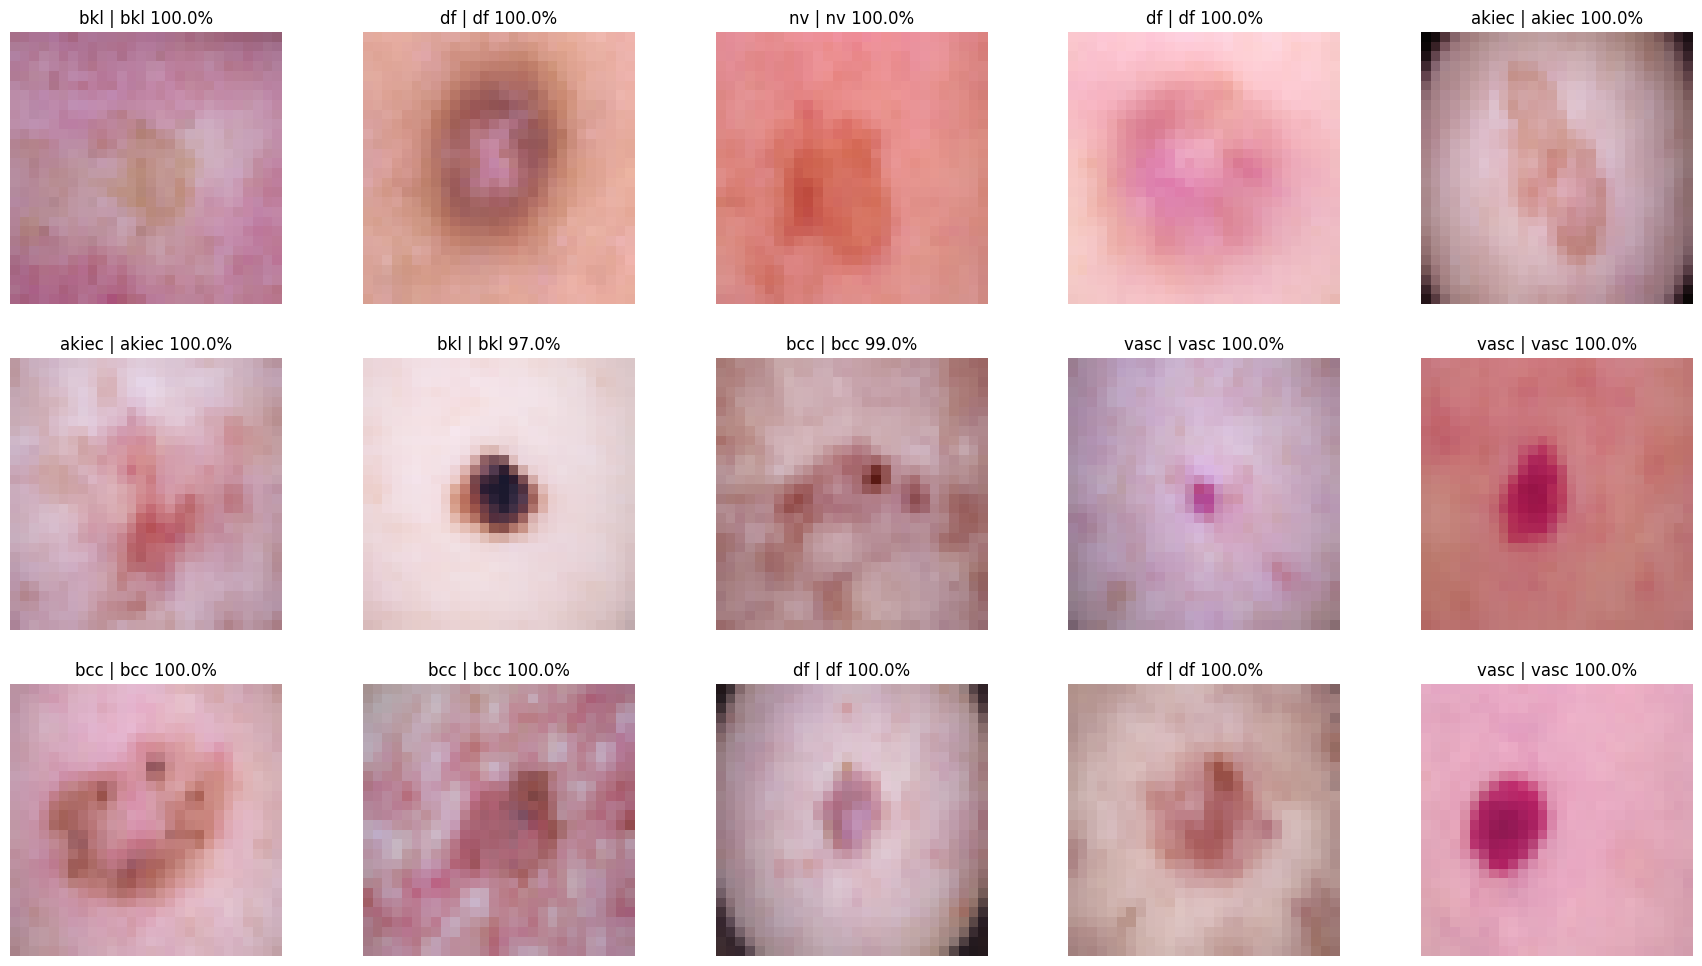

In [ ]:
plt.figure(figsize=(22, 12))
for i in range(15):
  plt.subplot(3, 5, i + 1)
  plt.imshow(sample_data[i])
  prediction_probability = np.amax(prediction[i]).round(2)
  plt.title(label_mapping[y_true[i][0]] + ' | ' + label_mapping[y_pred[i]] + ' ' + str(prediction_probability*100)+ '%' )
  plt.axis("off")
plt.show()

In [ ]:
import itertools

def plot_confusion_matrix(cm, classes, name, normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(name)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.show()

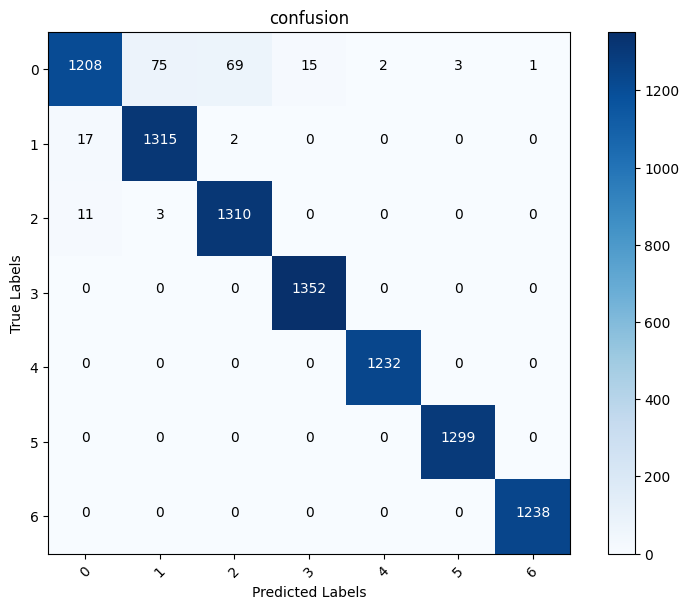

In [ ]:

def create_confusion_matrix(model, x_test_normalized, y_test, cm_plot_labels, name, y_true,y_pred):

    y_predict_classes, y_true_classes = y_pred, y_true
    confusion_matrix_computed = confusion_matrix(y_true_classes, y_predict_classes)
    plot_confusion_matrix(confusion_matrix_computed, cm_plot_labels, name)

create_confusion_matrix(model, X_test, Y_test, label_mapping, 'confusion', y_true, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
prediction per disease
> nv : 97.58000183105469 %
> mel : 0.009999999776482582 %
> bkl : 2.369999885559082 %
> bcc : 0.03999999910593033 %
> akiec : 0.0 %
> vasc : 0.0 %
> df : 0.0 %


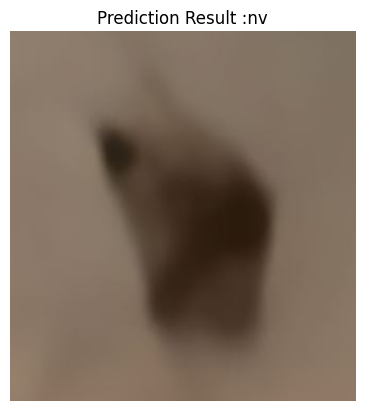

In [ ]:
test_img = image.load_img('/content/Mack_Horton_Skin.jpg', target_size=((28,28)))
test_img = image.img_to_array(test_img)
test_img = np.expand_dims(test_img, axis=0)
prediction = model.predict(test_img)
prediction_idx = np.argmax(prediction)
test_image = plt.imread('/content/Mack_Horton_Skin.jpg')
plt.imshow(test_image)
plt.title('Prediction Result :' + label_mapping[prediction_idx])
plt.axis("off")

print('===============================')
print('prediction per disease')
print('===============================')
for i in range(7):
  print(f'> {label_mapping[i]} : {(prediction[0][i]*100).round(2)} %')
print('===============================')
